
# TEL351 - Tarea 2 — Redes de Información en Noticias: centralidad, comunidades y conclusiones

Nombre: Pedro Arce

## Objetivos

- Construir un **grafo** a partir del corpus de la Tarea 1 (noticias originales + noticias generadas por agentes) siguiendo **reglas formales** de nodos y aristas.

- Calcular **métricas de centralidad** (grado, intermediación, cercanía y PageRank) y **detectar comunidades**.

- Elaborar **visualizaciones** que permitan **explicar** qué temas/noticias/agentes son más relevantes y **por qué**.

- Redactar **conclusiones** que relacionen métricas con fenómenos concretos del corpus (temas, fuentes, agentes).

## Parte 1: Preparación del corpus


### Instrucciones:

- Lee los datos de la Tarea 1 desde la carpeta `datos/` (noticias originales + generadas por agentes).
- Quita HTML, normaliza acentos, minúsculas, elimina *stopwords* en español.
- Guarda el corpus limpio como `datos/corpus_t2_limpio.json`.
- Muestra una tabla con número de documentos finales por **agente** y por **categoría** (si existe), y muestras (5–10 títulos por agente).

In [1]:
#Comentar en caso de tener ya instalados los paquetes
%pip install pandas beautifulsoup4 --quiet
%pip install -U spacy spacy-lookups-data --quiet
%pip install -q networkx
%pip install -q python-louvain
!python -m spacy download es_core_news_md  #opcion b: !python -m spacy download es_core_news_sm

import re, json, html, unicodedata, re, importlib, spacy, json
from pathlib import Path
from datetime import datetime
from collections import Counter
from scipy import sparse
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib as mpl

try:
    import pandas as pd
except ModuleNotFoundError as e:
    raise RuntimeError("Falta pandas. Ejecuta: %pip install pandas") from e

#display seguro (Jupyter) o print (fallback)
try:
    from IPython.display import display
except Exception:
    display = print

#Intento opcional de BeautifulSoup (si no esta, se cae a regex)
try:
    from bs4 import BeautifulSoup
except Exception:
    BeautifulSoup = None

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.5/98.5 MB 9.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 MB 14.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
###Helpers de limpieza (auto-contenidos, sin flags globales)
#Quita HTML/URLs/signos/digitos.
#Normaliza a minúsculas y sin tildes (preservando ñ/ü).
#Elimina stopwords (lista base en español).

STOPWORDS_ES = {
    "a","acá","ahí","al","algo","algún","alguna","algunas","alguno","algunos","allá","allí","ante","antes",
    "aquel","aquella","aquellas","aquello","aquellos","aquí","así","aún","aunque","bajo","bastante","bien","cada",
    "casi","como","con","contra","cual","cuales","cualquier","cualquiera","cualquieras","cuando","cuanta","cuantas",
    "cuanto","cuantos","de","debe","debemos","deben","deber","debería","deberías","deberían","debes","del","desde",
    "después","donde","dos","el","él","ella","ellas","ello","ellos","en","encima","entonces","entre","era","eras",
    "erais","eran","eres","es","esa","esas","ese","eso","esos","esta","estaba","estabais","estaban","estabas","estado",
    "estados","estáis","estamos","están","estar","estará","estarás","estaré","estaría","estas","este","esto","estos",
    "estoy","estuvo","fue","fueron","fui","fuimos","gran","ha","habéis","haber","había","habíais","habíamos","habían",
    "habías","habla","hablan","hace","hacen","hacer","hacia","hago","han","hasta","hay","he","hemos","hoy","la","las",
    "le","les","lo","los","más","me","menos","mi","mis","mientras","misma","mismas","mismo","mismos","muy","nada",
    "ni","no","nos","nosotras","nosotros","nuestra","nuestras","nuestro","nuestros","nunca","o","os","otra","otras",
    "otro","otros","para","parece","pero","poco","por","porque","que","qué","quien","quién","quienes","quienesquiera",
    "quiere","sabe","saber","se","sea","sean","según","ser","será","serán","sería","si","sí","siempre","siendo","sin",
    "sobre","sois","solamente","solo","sólo","somos","son","soy","su","sus","tal","también","tampoco","tan","tanta",
    "tantas","tanto","tantos","te","tenéis","tenemos","tener","tengo","ti","tiene","tienen","toda","todas","todavía",
    "todo","todos","tras","tu","tus","un","una","unas","uno","unos","usted","ustedes","va","vamos","van","vaya","verdad",
    "vosotras","vosotros","voy","ya","yo"
}

URL_RE        = re.compile(r"https?://\S+|www\.\S+", re.IGNORECASE)
TAG_RE        = re.compile(r"<[^>]+>")
MULTI_WS_RE   = re.compile(r"\s+")
#Conservamos # y @ por si luego se grafican hashtags/usuarios
PUNCT_NUM_RE  = re.compile(r"[^a-záéíóúñü\s#@]")  #elimina signos y digitos

def strip_html(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = html.unescape(text)
    if BeautifulSoup is not None:
        try:
            return BeautifulSoup(text, "html.parser").get_text(" ")
        except Exception:
            pass
    return TAG_RE.sub(" ", text)

def normalize_accents_lower(text: str) -> str:
    #minusculas + eliminacion de tildes, preservando ñ/ü
    text = text.lower()
    text = text.replace("ñ", "##enye##").replace("ü", "##udi##")
    text = unicodedata.normalize("NFKD", text)
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    text = text.replace("##enye##", "ñ").replace("##udi##", "ü")
    return text

def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = strip_html(text)
    text = URL_RE.sub(" ", text)
    text = normalize_accents_lower(text)
    text = PUNCT_NUM_RE.sub(" ", text)
    text = MULTI_WS_RE.sub(" ", text).strip()
    tokens = [t for t in text.split() if t not in STOPWORDS_ES and len(t) > 2]
    return " ".join(tokens)

In [3]:
###Detección de 'datos/' y carga robusta del CSV original
#Detecta 'datos/' (varios candidatos).
#Lee 'cnnchile_noticias.csv' probando encodings y separadores.
#Normaliza nombres de columnas a: titulo, cuerpo, categoria, fecha, url, indice_original.

#Localizar carpeta `datos/`
CANDIDATOS = [
    Path.cwd() / "datos",
    Path("/content/datos"),
    Path("/datos"),
    Path("/mnt/data/datos"),
]
DATOS_DIR = next((d for d in CANDIDATOS if d.exists() and d.is_dir()), None)
if DATOS_DIR is None:
    raise FileNotFoundError("No se encontró la carpeta 'datos/'.")

print("DATOS_DIR =", DATOS_DIR)

#Archivo original esperado
ORIGINAL_FILE = DATOS_DIR / "cnnchile_noticias.csv"
if not ORIGINAL_FILE.exists():
    candidatos = [p.name for p in DATOS_DIR.glob("*.csv")]
    print("No se encontro cnnchile_noticias.csv. CSVs en 'datos/':", candidatos)
    raise FileNotFoundError("No existe 'cnnchile_noticias.csv' en 'datos/'.")

print("CSV original:", ORIGINAL_FILE.name)

#Lector robusto
def read_csv_smart(path: Path, encodings=("utf-8","utf-8-sig","latin1","cp1252"),
                   seps=(",", ";", "\t", "|")):
    last_err = None
    for enc in encodings:
        for sep in seps:
            try:
                df = pd.read_csv(path, encoding=enc, sep=sep)
                if df.shape[1] >= 2:
                    return df, enc, sep
            except Exception as e:
                last_err = e
                continue
    raise RuntimeError(f"No se pudo leer {path.name} con enc/separador conocidos. Ultimo error: {last_err}")

df_orig, used_enc, used_sep = read_csv_smart(ORIGINAL_FILE)
print(f"Leído OK → encoding='{used_enc}', sep='{used_sep}', shape={df_orig.shape}")

#Normalizacion de columnas
def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    lower_map = {c: c.lower() for c in df.columns}
    inv_lower = {v: k for k, v in lower_map.items()}

    grupos = {
        "titulo": {"titulo","título","title","titular","headline"},
        "cuerpo": {"cuerpo","contenido","texto","body","article","articulo","artículo","noticia","descripcion","descripción","resumen"},
        "categoria": {"categoria","categoría","seccion","sección","tag","etiqueta","topic","seccion_noticia","categoria_noticia"},
        "fecha": {"fecha","date","fecha_publicacion","fecha publicación","published","published_at","datepublished","publicado"},
        "url": {"url","enlace","link","href"},
        "indice_original": {"indice_original","índice_original","indice","índice","id","id_noticia","idx","index"},
    }

    colmap = {}
    for canon, candidates in grupos.items():
        present = [inv_lower[c] for c in candidates if c in lower_map.values()]
        if present:
            colmap[present[0]] = canon

    df2 = df.rename(columns=colmap)

    #Asegurar 'indice_original'
    if "indice_original" not in df2.columns:
        df2 = df2.reset_index().rename(columns={"index": "indice_original"})

    #Validacion min
    faltantes = [c for c in ["titulo","cuerpo"] if c not in df2.columns]
    if faltantes:
        raise ValueError(f"Faltan columnas requeridas en original: {faltantes}.")

    print("Columnas tras normalizar:", list(df2.columns))
    return df2

df_orig = normalize_columns(df_orig)
print("Filas originales:", len(df_orig))
display(df_orig.head(3))

DATOS_DIR = /content/datos
CSV original: cnnchile_noticias.csv
Leído OK → encoding='utf-8', sep=',', shape=(130, 5)
Columnas tras normalizar: ['indice_original', 'titulo', 'fecha', 'cuerpo', 'url', 'categoria']
Filas originales: 130


,indice_original,titulo,fecha,cuerpo,url,categoria
0,0,Cómo Pedro Pascal se convirtió en el actor más...,2025-08-31T18:38:00,Con una carrera que comenzó hace más de 25 año...,https://www.cnnchile.com/cultura/como-pedro-pa...,cultura
1,1,Durán explica por qué no se suspendió el parti...,2025-08-31T18:36:00,"Según explicó la autoridad, un análisis de Car...",https://www.cnnchile.com/pais/delegado-duran-n...,pais
2,2,Tras muerte de hincha en Monumental: Alcalde d...,2025-08-31T18:08:00,El jefe comunal advirtió que actualmente no ex...,https://www.cnnchile.com/pais/alcalde-independ...,pais


In [4]:
###Carga robusta de CSVs de agentes y estandarización =========
#Busca archivos 'agente_*.csv' en `datos/`.
#Lee con read_csv_smart y mapea columnas a: indice_original, resultado, titulo_original, fecha.
#Agrega '_agente_name' desde el nombre del archivo.

#Listar archivos de agentes
agent_files = sorted([p for p in DATOS_DIR.glob("agente_*.csv") if p.is_file()])
if not agent_files:
    print("No se encontraron archivos 'agente_*.csv' en 'datos/'.")
else:
    print("Agentes detectados:", [p.name for p in agent_files])

def infer_agent_name(path: Path) -> str:
    stem = path.stem  #sin extensión
    stem = stem.replace("agente_", "Agente").replace("Agente_", "Agente")
    parts = re.split(r"[-_ ]+", stem)
    return "".join(w.capitalize() for w in parts)

def normalize_agent_columns(df: pd.DataFrame) -> pd.DataFrame:
    lower_map = {c: c.lower() for c in df.columns}
    inv_lower = {v: k for k, v in lower_map.items()}

    grupos = {
        "indice_original": {"indice_original","índice_original","indice","índice","id","id_noticia","idx","index","indice_corpus"},
        "resultado": {"resultado","output","texto","generado","contenido","respuesta","result"},
        "titulo_original": {"titulo_original","título_original","titulo","title","headline","titular"},
        "fecha": {"fecha","date","published_at","datepublished"},
    }

    colmap = {}
    for canon, candidates in grupos.items():
        present = [inv_lower[c] for c in candidates if c in lower_map.values()]
        if present:
            colmap[present[0]] = canon

    df2 = df.rename(columns=colmap)

    faltantes = [c for c in ["indice_original","resultado"] if c not in df2.columns]
    if faltantes:
        raise ValueError(f"CSV de agente sin columnas mínimas {faltantes}.")

    return df2

agent_frames = []
for p in agent_files:
    try:
        df_a, enc, sep = read_csv_smart(p)
        df_a = normalize_agent_columns(df_a)
        df_a["_agente_name"] = infer_agent_name(p)
        agent_frames.append(df_a)
        print(f"OK {p.name} → encoding='{enc}', sep='{sep}', shape={df_a.shape}, agente='{df_a._agente_name.iloc[0]}'")
    except Exception as e:
        print(f"Omitido {p.name}: {e}")

df_agents = pd.concat(agent_frames, ignore_index=True) if agent_frames else pd.DataFrame()
print("Filas totales (agentes):", len(df_agents))
display(df_agents.head(3) if not df_agents.empty else "—")

Agentes detectados: ['agente_analista_de_datos.csv', 'agente_analogador_creativo.csv', 'agente_hashtagero_estrategico.csv', 'agente_preguntador_curioso.csv', 'agente_titulares_impactantes.csv']
OK agente_analista_de_datos.csv → encoding='utf-8', sep=',', shape=(10, 6), agente='AgenteanalistaDeDatos'
OK agente_analogador_creativo.csv → encoding='utf-8', sep=',', shape=(10, 6), agente='AgenteanalogadorCreativo'
OK agente_hashtagero_estrategico.csv → encoding='utf-8', sep=',', shape=(10, 6), agente='AgentehashtageroEstrategico'
OK agente_preguntador_curioso.csv → encoding='utf-8', sep=',', shape=(10, 6), agente='AgentepreguntadorCurioso'
OK agente_titulares_impactantes.csv → encoding='utf-8', sep=',', shape=(10, 6), agente='AgentetitularesImpactantes'
Filas totales (agentes): 50


,indice_original,titulo_original,categoria,url,resultado,_agente_name
0,10,Superclásico 198: Universidad de Chile sufre l...,deportes,https://www.cnnchile.com/deportes/superclasico...,ANÁLISIS ESTADÍSTICO CONTEXTUALIZADO: Superclá...,AgenteanalistaDeDatos
1,11,Este es el país más pacífico del mundo en 2025,mundo,https://www.cnnchile.com/mundo/este-es-el-pais...,ANÁLISIS ESTADÍSTICO CONTEXTUALIZADO: Este es ...,AgenteanalistaDeDatos
2,12,Xi y Modi hablan de amistad en un mundo “caóti...,mundo,https://www.cnnchile.com/mundo/xi-y-modi-habla...,ANÁLISIS ESTADÍSTICO CONTEXTUALIZADO: Xi y Mod...,AgenteanalistaDeDatos


In [5]:
###Unificar documentos (original + agentes) y limpiar
#Un doc por noticia original (tipo='original').
#Un doc por salida de agente (tipo='agente'), heredando 'categoria' desde la original.
#*_raw conserva texto sin limpiar; 'titulo'/'texto' van limpios.

#Comprobaciones suaves (para evitar NameError si el entorno se reinició)
if "df_orig" not in globals():
    raise RuntimeError("df_orig no existe. Ejecuta antes el Bloque 2-FIX.")
if "df_agents" not in globals():
    raise RuntimeError("df_agents no existe. Ejecuta antes el Bloque 3-FIX (aunque no haya agentes).")

docs = []
orig_by_index = {}

#Originales
for _, row in df_orig.iterrows():
    idx_val     = pd.to_numeric(row.get("indice_original", _), errors="coerce")
    idx         = int(idx_val) if pd.notna(idx_val) else int(_)
    titulo_raw  = str(row.get("titulo", "") or "")
    cuerpo_raw  = str(row.get("cuerpo", "") or "")
    categoria   = row.get("categoria", None)
    fecha       = row.get("fecha", None)
    url         = row.get("url", None)

    doc = {
        "id": f"art_{idx}",
        "tipo": "original",
        "indice_original": idx,
        "categoria": (categoria if pd.notna(categoria) else None),
        "fecha": (str(fecha) if (fecha is not None and str(fecha) != "nan") else None),
        "titulo": clean_text(titulo_raw),
        "texto": clean_text(cuerpo_raw),
        "titulo_raw": titulo_raw,
        "texto_raw": cuerpo_raw,
        "url": (url if pd.notna(url) else None),
    }
    docs.append(doc)
    orig_by_index[idx] = doc

#Agentes (si existen)
if not df_agents.empty:
    for _, row in df_agents.iterrows():
        idx_val     = pd.to_numeric(row.get("indice_original", -1), errors="coerce")
        idx         = int(idx_val) if pd.notna(idx_val) else -1
        agente_name = str(row.get("_agente_name", "Agente"))
        titulo_ori  = str(row.get("titulo_original", "") or "")
        resultado_rw= str(row.get("resultado", "") or "")
        fecha       = row.get("fecha", None)

        categoria = orig_by_index.get(idx, {}).get("categoria", None)

        doc = {
            "id": f"{agente_name}__art_{idx}",
            "tipo": "agente",
            "agente": agente_name,
            "indice_original": idx,
            "categoria": categoria,
            "fecha": (str(fecha) if (fecha is not None and str(fecha) != "nan") else None),
            "titulo": clean_text(titulo_ori) if titulo_ori else None,
            "texto": clean_text(resultado_rw),
            "titulo_raw": titulo_ori if titulo_ori else None,
            "texto_raw": resultado_rw
        }
        docs.append(doc)

print("Total documentos unificados:", len(docs))

Total documentos unificados: 180


In [6]:
###Guardar JSON limpio
#Guarda 'docs' + metadatos en datos/corpus_t2_limpio.json

meta = {
    "fuente_original_csv": str(ORIGINAL_FILE),
    "agentes_csv": [str(p) for p in agent_files],
    "fecha_procesamiento": datetime.now().isoformat(timespec="seconds"),
    "version": "t2.0"
}
corpus = {"meta": meta, "docs": docs}

DATOS_DIR.mkdir(parents=True, exist_ok=True)
out_path = DATOS_DIR / "corpus_t2_limpio.json"
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(corpus, f, ensure_ascii=False, indent=2)

print("Guardado:", out_path)

Guardado: /content/datos/corpus_t2_limpio.json


In [7]:
###Resúmenes y muestras de titulos
#Tabla: # documentos por agente (solo tipo 'agente').
#Tabla: # documentos por categoria (ambos tipos).
#Muestras: hasta 10 titulos por agente (fallback a snippet del texto del agente).

df_docs = pd.DataFrame(docs)

if df_docs.empty:
    raise RuntimeError("No hay documentos. Revisa los CSVs en 'datos/'.")

#Conteo por agente
if "agente" in df_docs.columns:
    df_ag_count = (
        df_docs[df_docs["tipo"] == "agente"]
        .groupby("agente", dropna=False)["id"].count()
        .reset_index().rename(columns={"id": "num_docs"})
        .sort_values("num_docs", ascending=False)
    )
    print("\n### Documentos por agente")
    display(df_ag_count)

#Conteo por categoria
if "categoria" in df_docs.columns:
    df_cat_count = (
        df_docs.groupby(["tipo", "categoria"], dropna=False)["id"].count()
        .reset_index().rename(columns={"id": "num_docs"})
        .sort_values(["tipo", "num_docs"], ascending=[True, False])
    )
    print("\n### Documentos por categoria (tipo + categoria)")
    display(df_cat_count)

#Muestras de titulos por agente (max 10)
samples = []
if "agente" in df_docs.columns:
    for ag, sub in df_docs[df_docs["tipo"]=="agente"].groupby("agente"):
        titles = [t for t in sub["titulo_raw"].fillna("").tolist() if t][:10]
        if not titles:
            titles = [ (str(x).strip().replace("\n"," ")[:80] + "…")
                       for x in sub["texto_raw"].fillna("").tolist()[:10] if str(x).strip() ]
        samples.append({"agente": ag, "muestras_titulos": titles})

    df_samples = pd.DataFrame(samples)
    print("\n### Muestras de 5–10 titulos por agente")
    display(df_samples)


### Documentos por agente


,agente,num_docs
0,AgenteanalistaDeDatos,10
1,AgenteanalogadorCreativo,10
2,AgentehashtageroEstrategico,10
3,AgentepreguntadorCurioso,10
4,AgentetitularesImpactantes,10



### Documentos por categoria (tipo + categoria)


,tipo,categoria,num_docs
3,agente,pais,19
2,agente,mundo,15
1,agente,deportes,12
0,agente,cultura,4
9,original,pais,64
7,original,mundo,30
6,original,deportes,16
5,original,cultura,13
8,original,negocios,3
10,original,servicios,3



### Muestras de 5–10 titulos por agente


,agente,muestras_titulos
0,AgenteanalistaDeDatos,[Superclásico 198: Universidad de Chile sufre ...
1,AgenteanalogadorCreativo,[Matthei afirma que “al principio” de un gobie...
2,AgentehashtageroEstrategico,[“Me desmayé por estrés”: Endler revela secuel...
3,AgentepreguntadorCurioso,[“Volveremos siendo aún más”: Greta Thunberg a...
4,AgentetitularesImpactantes,[Cómo Pedro Pascal se convirtió en el actor má...


## Parte 2: Extracción de representaciones


### Instrucciones:

- Extrae entidades NER (usa `spaCy` u otra) para extraer **PERSON**, **ORG**, **GPE**, **LOC**.
- **Normaliza** entidades (casing, variantes, alias sencillos).
- Guarda por noticia una lista de términos clave o entidades en `datos/features_t2.json`.

In [8]:
###Cargar spaCy con prioridad MD y fallback
#Cambios respecto al Bloque 7 original:
#Forzamos prioridad a `es_core_news_md` (mejor recall que 'sm').
#Fallback a `es_core_news_sm` y luego `xx_ent_wiki_sm`.
#Si no hay modelos, activamos SIMPLE_FALLBACK (heuristico) y creamos nlp en blanco.

NLP = None
SIMPLE_FALLBACK = False

def load_spacy_nlp_colab():
    global SIMPLE_FALLBACK
    for pkg in ("es_core_news_md", "es_core_news_sm", "xx_ent_wiki_sm"):
        try:
            importlib.import_module(pkg)
            nlp = spacy.load(pkg)
            print(f"spaCy cargado con: {pkg}")
            SIMPLE_FALLBACK = False
            return nlp
        except Exception:
            continue
    SIMPLE_FALLBACK = True
    print("No hay modelo NER disponible. Usando extractor heuristico SIMPLE_FALLBACK.")
    return spacy.blank("es")

NLP = load_spacy_nlp_colab()

spaCy cargado con: es_core_news_md


In [9]:
###Normalización, alias y filtros de calidad para entidades

def strip_accents(s: str) -> str:
    s = unicodedata.normalize("NFKD", s)
    return "".join(ch for ch in s if not unicodedata.combining(ch))

def canonical_key(s: str) -> str:
    return re.sub(r"\s+", " ", strip_accents((s or "")).strip().lower())

#ALIAS (clave en minúsculas sin tildes) -> Forma canónica
ALIAS_MAP = {
    #Paises / bloques
    "eeuu": "Estados Unidos", "ee.uu.": "Estados Unidos", "e.e.u.u.": "Estados Unidos",
    "ee uu": "Estados Unidos", "usa": "Estados Unidos", "u.s.a.": "Estados Unidos",
    "union europea": "Unión Europea", "ue": "Unión Europea",
    "reino unido": "Reino Unido", "gran bretana": "Reino Unido", "gran bretaña": "Reino Unido",
    "corea del sur": "Corea del Sur", "corea del norte": "Corea del Norte",
    #Chile
    "chile": "Chile", "santiago de chile": "Santiago", "santiago": "Santiago",
    "valparaiso": "Valparaíso", "biobio": "Biobío",
    #Partidos/organismos CL
    "rn": "Renovación Nacional", "udi": "Unión Demócrata Independiente",
    "ps": "Partido Socialista de Chile", "pc": "Partido Comunista de Chile",
    "pdi": "Policía de Investigaciones de Chile",
    "carabineros": "Carabineros de Chile",
    #Medios/org
    "cnn chile": "CNN Chile",
    "gobierno de chile": "Gobierno de Chile",
    #Universidades
    "u de chile": "Universidad de Chile", "u. de chile": "Universidad de Chile", "udechile": "Universidad de Chile",
}

#Gazetteers (para corregir a GPE)
GPE_NAMES = {
    # Países (subset útil)
    "chile","argentina","brasil","estados unidos","peru","perú","bolivia","colombia","venezuela","mexico","méxico",
    "uruguay","paraguay","espana","españa","francia","reino unido","alemania","italia","china","japon","japón",
    "corea del sur","corea del norte","rusia","ucrania","israel","palestina",
    #Ciudades (subset)
    "santiago","valparaiso","valparaíso","concepcion","concepción","la serena","antofagasta","temuco","iquique",
    "puerto montt","valdivia","rancagua","buenos aires","lima","bogota","bogotá","caracas","mexico df","ciudad de mexico","madrid",
    "barcelona","paris","parís","roma","londres","washington","beijing","pekin","pekín","shanghai","tokio","seul","seúl","moscu","moscú","kiev",
}

#Lista de "pseudo-entidades" a excluir por ruido
STOP_ENTITIES = {
    "informacion","información","actualizacion","actualización","cultura","deporte","economia","economía",
    "politica","política","nacionales","internacional","opinion","opinión","presencia","contexto","analisis",
    "análisis","profundizar","preguntas","resumen","noticia","contenido","nota","reporte","fuente","video","imagen",
}

def normalize_entity_text(text: str, label: str) -> str:
    raw = (text or "").strip()
    if not raw:
        return raw
    key = canonical_key(raw)
    if key in ALIAS_MAP:
        return ALIAS_MAP[key]
    #Title Case salvo acronimos puros (3–6 letras)
    def _fix_token(t):
        return t if re.fullmatch(r"[A-Z]{2,6}", t) else t.capitalize()
    return " ".join(_fix_token(w) for w in raw.split())

def is_noise_entity(text: str) -> bool:
    if not text:
        return True
    t = text.strip()
    key = canonical_key(t)
    if key in STOP_ENTITIES:
        return True
    if t.endswith(":"):
        return True
    if re.search(r"[•·•\*•\-]$", t):
        return True
    #demasiados signos o muy corto
    if len(re.sub(r"[A-Za-zÁÉÍÓÚÑÜáéíóúñü]", "", t)) > len(t)/2:
        return True
    if len(t) < 2:
        return True
    return False

#Correccion de etiquetas por gazetteer (GPE domina sobre LOC/ORG)
def correct_label_by_gazetteer(text: str, label: str) -> str:
    key = canonical_key(text)
    if key in GPE_NAMES:
        return "GPE"
    return label

#Forzar etiqueta para casos frecuentes mal clasificados
FORCE_LABEL = {
    "xi jinping": "PERSON", "pedro pascal": "PERSON", "jair bolsonaro": "PERSON", "vicente pizarro": "PERSON",
}
def force_label_if_needed(text: str, label: str) -> str:
    key = canonical_key(text)
    return FORCE_LABEL.get(key, label)


In [10]:
###Cargar corpus y usar SIEMPRE texto RAW para NER

#Detectar 'datos/'
if "DATOS_DIR" not in globals():
    CANDIDATOS = [Path.cwd()/ "datos", Path("/content/datos"), Path("/datos"), Path("/mnt/data/datos")]
    DATOS_DIR = next((d for d in CANDIDATOS if d.exists() and d.is_dir()), None)
    if DATOS_DIR is None:
        raise FileNotFoundError("No se encontró carpeta 'datos/'.")

CORPUS_JSON = DATOS_DIR / "corpus_t2_limpio.json"
if not CORPUS_JSON.exists() and "docs" not in globals():
    raise FileNotFoundError("Falta corpus_t2_limpio.json y no hay 'docs' en memoria.")

DOCS_T2 = []
if CORPUS_JSON.exists():
    with open(CORPUS_JSON, "r", encoding="utf-8") as f:
        data = json.load(f)
    src_docs = data.get("docs", [])
else:
    src_docs = docs  #de memoria

for d in src_docs:
    titulo_src = d.get("titulo_raw") or d.get("titulo") or ""
    texto_src  = d.get("texto_raw")  or d.get("texto")  or ""
    texto_base_raw = f"{str(titulo_src).strip()}\n{str(texto_src).strip()}".strip()
    DOCS_T2.append({
        "id": d.get("id"),
        "tipo": d.get("tipo"),
        "categoria": d.get("categoria"),
        "fecha": d.get("fecha"),
        "texto_base_raw": texto_base_raw
    })

print(f"Documentos para NER (raw): {len(DOCS_T2)}")
print("Ejemplo:", DOCS_T2[0]["id"] if DOCS_T2 else "—")


Documentos para NER (raw): 180
Ejemplo: art_0


In [11]:
###Extraccion NER mejorada + filtros + correcciones
#Ejecuta NER sobre RAW.
#Aplica normalizacion, filtros de ruido y correccion de etiquetas (gazetteer/forzadas).
#Añade una heurística de respaldo para PERSON (Nombre Apellido) si spaCy falla.

TARGET_LABELS = {"PERSON","ORG","GPE","LOC"}

#Heuristica PERSON: busca patrones Nombre Apellido no capturados
PERSON_PATTERN = re.compile(r"\b([A-ZÁÉÍÓÚÑÜ][a-záéíóúñü]{2,})(?:\s+de)?\s+([A-ZÁÉÍÓÚÑÜ][a-záéíóúñü]{2,})\b")

def extract_with_spacy(text: str):
    ents = {"PERSON": set(), "ORG": set(), "GPE": set(), "LOC": set()}
    if NLP is None or SIMPLE_FALLBACK or "ner" not in getattr(NLP, "pipe_names", []):
        return ents
    doc = NLP(text)
    for e in doc.ents:
        if e.label_ in TARGET_LABELS:
            norm = normalize_entity_text(e.text, e.label_)
            if is_noise_entity(norm):
                continue
            lab = correct_label_by_gazetteer(norm, e.label_)
            lab = force_label_if_needed(norm, lab)
            ents[lab].add(norm)
    return ents

def extract_with_heuristics(text: str):
    #baseline simple: capitalizados → ORG, más gazetteer para GPE/LOC
    res = {"PERSON": set(), "ORG": set(), "GPE": set(), "LOC": set()}
    #candidatos capitalizados multi-palabra
    cands = set(re.findall(r"\b(?:[A-ZÁÉÍÓÚÑÜ][a-záéíóúñü]+(?:\s+[A-ZÁÉÍÓÚÑÜ][a-záéíóúñü]+){0,4})\b", text))
    for c in cands:
        norm = normalize_entity_text(c, "ORG")
        if is_noise_entity(norm):
            continue
        lab = correct_label_by_gazetteer(norm, "ORG")
        lab = force_label_if_needed(norm, lab)
        res[lab].add(norm)
    #Heuristica GPE por gazetteer si no aparecio
    low = canonical_key(text)
    for name in GPE_NAMES:
        if name in low:
            norm = normalize_entity_text(name, "GPE")
            res["GPE"].add(norm)
    #Heuristica PERSON por patron
    for m in PERSON_PATTERN.finditer(text):
        cand = f"{m.group(1)} {m.group(2)}"
        norm = normalize_entity_text(cand, "PERSON")
        if not is_noise_entity(norm):
            res["PERSON"].add(norm)
    return res

def merge_and_fix(ents_spacy, ents_heur):
    #Combinar dando prioridad a spaCy
    out = {k: set(v) for k, v in ents_spacy.items()}
    for k in TARGET_LABELS:
        out[k] |= ents_heur.get(k, set())
    #Si una entidad aparece en varias etiquetas, resolvemos prioridad: PERSON > ORG > GPE > LOC
    priority = ["PERSON","ORG","GPE","LOC"]
    final = {k: set() for k in TARGET_LABELS}
    all_terms = set().union(*out.values())
    #map term -> best label
    for t in all_terms:
        best = None
        for lab in priority:
            if t in out[lab]:
                best = lab
                break
        #correccion final por gazetteer/forzadas
        best = correct_label_by_gazetteer(t, best)
        best = force_label_if_needed(t, best)
        final[best].add(t)
    return final

DOC_ENTS = {}
GLOBAL_COUNTS = Counter()

for d in DOCS_T2:
    text = d["texto_base_raw"]
    ents_spa = extract_with_spacy(text)
    ents_heu = extract_with_heuristics(text)
    ents = merge_and_fix(ents_spa, ents_heu)

    typed_lists = {k: sorted(v) for k, v in ents.items()}
    terms = sorted(set().union(*typed_lists.values()))

    DOC_ENTS[d["id"]] = {
        "id": d["id"],
        "tipo": d["tipo"],
        "categoria": d["categoria"],
        "fecha": d["fecha"],
        "entities": typed_lists,
        "terms": terms
    }
    for t in terms:
        GLOBAL_COUNTS[t] += 1

print("Extraccion mejorada completada para", len(DOC_ENTS), "documentos.")
print("Top términos (muestra):", GLOBAL_COUNTS.most_common(10))

Extraccion mejorada completada para 180 documentos.
Top términos (muestra): [('Matucana', 136), ('Estadio Nacional', 130), ('GAM', 130), ('Matucana 100', 130), ('Movistar Arena', 130), ('Con', 129), ('El', 108), ('La', 83), ('En', 74), ('Chile', 59)]


In [12]:
###Guardar features corregidas

FEATURES_PATH = DATOS_DIR / "features_t2.json"
meta_model = None
try:
    meta_model = getattr(NLP, "meta", {}).get("name")
except Exception:
    meta_model = None

out = {
    "meta": {
        "fuente": str(CORPUS_JSON) if 'CORPUS_JSON' in globals() and CORPUS_JSON else "memoria/docs",
        "modelo_spacy": meta_model if not SIMPLE_FALLBACK else "SIMPLE_FALLBACK",
        "usa_texto_raw_para_ner": True,
        "heuristico_activado": bool(SIMPLE_FALLBACK),
        "fecha_procesamiento": datetime.now().isoformat(timespec="seconds"),
        "labels_objetivo": sorted(list(TARGET_LABELS)),
        "alias_count": len(ALIAS_MAP),
        "gpe_gazetteer_count": len(GPE_NAMES)
    },
    "features": DOC_ENTS
}

with open(FEATURES_PATH, "w", encoding="utf-8") as f:
    json.dump(out, f, ensure_ascii=False, indent=2)

print("Guardado (corregido):", FEATURES_PATH)


Guardado (corregido): /content/datos/features_t2.json


In [13]:
###Reporte de calidad (antes de construir grafos)
#Top-15 entidades por tipo (frecuencia por documentos).
#Ejemplos de documentos con PERSON ahora detectado.

#Construir matriz doc->labels count
rows = []
type_presence = Counter()
for docid, feat in DOC_ENTS.items():
    row = {"id": docid}
    for t in ("PERSON","ORG","GPE","LOC"):
        n = len(feat["entities"][t])
        row[t] = n
        if n > 0:
            type_presence[t] += 1
    rows.append(row)

df_q = pd.DataFrame(rows)
total_docs = len(df_q)
print(f"Total documentos: {total_docs}")

for t in ("PERSON","ORG","GPE","LOC"):
    pct = 100.0 * type_presence[t] / total_docs if total_docs else 0.0
    print(f"- Docs con ≥1 {t}: {type_presence[t]} ({pct:.1f}%)")

#Top-15 por tipo (conteo por documentos)
def top_by_type(label, k=15):
    c = Counter()
    for feat in DOC_ENTS.values():
        for e in feat["entities"][label]:
            c[e] += 1
    return pd.DataFrame(c.most_common(k), columns=[label, "docs"])

print("\nTop entidades por tipo:")
for t in ("PERSON","ORG","GPE","LOC"):
    print(f"\n>>> {t}")
    display(top_by_type(t, k=15))

#Muestras de 5 docs con PERSON detectado
docs_with_person = [d for d,f in DOC_ENTS.items() if len(f["entities"]["PERSON"])>0][:5]
print("\nEjemplos de docs con PERSON detectado:", docs_with_person)
for docid in docs_with_person[:3]:
    print(f"\n— {docid}")
    print("  PERSON:", DOC_ENTS[docid]["entities"]["PERSON"][:8])
    print("  ORG   :", DOC_ENTS[docid]["entities"]["ORG"][:8])
    print("  GPE   :", DOC_ENTS[docid]["entities"]["GPE"][:8])
    print("  LOC   :", DOC_ENTS[docid]["entities"]["LOC"][:8])


Total documentos: 180
- Docs con ≥1 PERSON: 159 (88.3%)
- Docs con ≥1 ORG: 180 (100.0%)
- Docs con ≥1 GPE: 126 (70.0%)
- Docs con ≥1 LOC: 140 (77.8%)

Top entidades por tipo:

>>> PERSON


,PERSON,docs
0,Estadio Nacional,130
1,Movistar Arena,130
2,Colo Colo,16
3,Universidad Chile,15
4,Estadio Monumental,8
5,Región Metropolitana,7
6,Jeannette Jara,7
7,José Antonio,6
8,Ministerio Público,6
9,Partido Comunista,6



>>> ORG


,ORG,docs
0,Matucana,136
1,Con,129
2,El,108
3,La,83
4,En,74
5,Este,39
6,No,30
7,Los,30
8,Las,28
9,Según,27



>>> GPE


,GPE,docs
0,Chile,59
1,Estados Unidos,19
2,Santiago,17
3,Israel,11
4,Mexico,8
5,Italia,8
6,Argentina,8
7,México,6
8,Japon,5
9,Japón,5



>>> LOC


,LOC,docs
0,GAM,130
1,Matucana 100,130
2,Línea 4,5
3,Metro De Santiago,5
4,En Estados Unidos,4
5,Aeropuerto De Santiago,3
6,Alcalde De Independencia,2
7,La India,2
8,Inapelable,2
9,Ministerio De Relaciones Exteriores De China,2



Ejemplos de docs con PERSON detectado: ['art_0', 'art_1', 'art_2', 'art_3', 'art_4']

— art_0
  PERSON: ['Baby Yoda', 'Chris Evans', 'Cómo Pedro', 'Dakota Johnson', 'Estadio Nacional', 'First Steps', 'Josh Brolin', 'Liane Hentscher']
  ORG   : ['Actualmente', 'Avengers', 'Blue', 'Buffy', 'CNN', 'Carol', 'Con', 'Cómo Pedro Pascal']
  GPE   : ['Chile', 'China', 'Estados Unidos', 'Mexico', 'Roma']
  LOC   : ['DC', 'GAM', 'King’s Landing', 'Matucana 100']

— art_1
  PERSON: ['Colo Colo', 'Estadio Monumental', 'Estadio Nacional', 'Fiscalía Flagrancia', 'Gonzalo Durán', 'Movistar Arena', 'Región Metropolitana', 'Universidad Chile']
  ORG   : ['Carabineros de Chile', 'Con', 'Cordillera', 'Durán', 'El', 'Flagrancia Oriente', 'La', 'La Fiscalía']
  GPE   : ['Chile']
  LOC   : ['GAM', 'Matucana 100']

— art_2
  PERSON: ['Agustín Iglesias', 'Alcalde Independencia', 'Colo Colo', 'Delegación Presidencial', 'Eloísa Díaz', 'Estadio Monumental', 'Estadio Nacional', 'Estadio Santa']
  ORG   : ['ANFP',

## Parte 3: Definición del grafo

Debes construir **al menos un grafo** de tipo noticia–noticia basado en las entidades extraídas en la Parte 2.


### Instrucciones:

- **Nodos:** cada noticia (usar `id`).

- **Aristas ponderadas:**

    - Calcula similitud entre pares de noticias usando sus listas de entidades (archivo `features_t2.json`).

    - Usa **Jaccard** o **coseno** sobre vectores binarios (cada entidad = 1 si aparece, 0 si no).

    - Crea arista entre noticias si `similitud ≥ τ`.

    - Usa τ en {0.20, 0.25, 0.30}. **Elige y justifica** el umbral (densidad razonable: 1–10 aristas por nodo, en promedio).   

    - Peso de la arista = valor de similitud (0–1).

- **Control de densidad:** si el grafo queda demasiado denso, aplica **k-NN por noticia** (p. ej. k=10 vecinos más similares) → para cada noticia conserva solo los k vecinos más similares.

In [14]:
###Cargar entities y preparar sets por documento
#Lee datos/features_t2.json y arma, para cada noticia (id), el conjunto de ENTIDADES.
#Usaremos PERSON, ORG, LOC (y GPE si existiera). Quedan listas unicas por doc.

#Detectar carpeta datos/ (Colab o local)
CANDIDATOS = [Path.cwd()/"datos", Path("/content/datos"), Path("/datos"), Path("/mnt/data/datos")]
DATOS_DIR = next((d for d in CANDIDATOS if d.exists() and d.is_dir()), None)
if DATOS_DIR is None:
    raise FileNotFoundError("No se encontró carpeta 'datos/'.")

FEATURES_PATH = DATOS_DIR / "features_t2.json"
with open(FEATURES_PATH, "r", encoding="utf-8") as f:
    FEATS = json.load(f)

FEATURES = FEATS["features"]  #dict: id_doc -> {..., entities: {PERSON, ORG, LOC, ...}}
ENTITY_TYPES = ["PERSON", "ORG", "LOC", "GPE"]  #GPE estará vacío si usaste spaCy ES puro

doc_ids = []
doc_entities = []  #lista de sets

for doc_id, payload in FEATURES.items():
    ents = payload.get("entities", {})
    s = set()
    for label in ENTITY_TYPES:
        for e in ents.get(label, []) or []:
            if e and isinstance(e, str):
                s.add(e)
    doc_ids.append(doc_id)
    doc_entities.append(s)

n_docs = len(doc_ids)
non_empty = sum(1 for s in doc_entities if len(s) > 0)
print(f"Docs: {n_docs} | Con >=1 entidad: {non_empty} | Sin entidades: {n_docs - non_empty}")

Docs: 180 | Con >=1 entidad: 180 | Sin entidades: 0


In [15]:
###Vectorización binaria
#Construye una matriz binaria sparse X de tamaño N_docs x N_entidades.
#Cada fila es una noticia; cada columna es una entidad distinta.

#Si faltan dependencias en tu entorno:
%pip install -q scikit-learn scipy

from sklearn.preprocessing import MultiLabelBinarizer
import numpy as np
from scipy import sparse

mlb = MultiLabelBinarizer(sparse_output=True)
X = mlb.fit_transform(doc_entities)     #CSR (N_docs x N_entidades)
vocab = mlb.classes_                    #array de entidades únicas
deg = np.asarray(X.sum(axis=1)).ravel() #nº entidades por doc

print(f"Matriz X: {X.shape[0]} docs x {X.shape[1]} entidades | Media entidades/doc: {deg.mean():.2f}")
print(f"Docs sin entidades: {(deg==0).sum()} (quedarán como nodos aislados si no tienen matches)")

Matriz X: 180 docs x 2824 entidades | Media entidades/doc: 31.61
Docs sin entidades: 0 (quedarán como nodos aislados si no tienen matches)


In [16]:
###Similitud por pares (Jaccard o Coseno) sobre binario
#Elegimos una métrica y computamos la matriz de intersecciones con X @ X.T (sparse).
#Jaccard(i,j) = |∩| / (|A| + |B| - |∩|)
#Cosine(i,j)  = |∩| / sqrt(|A|*|B|)
#la matriz resultante es simétrica; ponemos diag=0 y eliminamos ceros.


SIM_METRIC = "jaccard"  #"jaccard" o "cosine"

#Interseccion: cuantas entidades comparten dos documentos
A = (X @ X.T).tocsr().astype(np.float32)
A.setdiag(0.0)
A.eliminate_zeros()

rows, cols = A.nonzero()
inter = A.data
deg_i = deg[rows]
deg_j = deg[cols]

if SIM_METRIC.lower() == "jaccard":
    union = deg_i + deg_j - inter
    sim_data = np.divide(inter, union, out=np.zeros_like(inter), where=union>0)
elif SIM_METRIC.lower() == "cosine":
    denom = np.sqrt(deg_i * deg_j)
    sim_data = np.divide(inter, denom, out=np.zeros_like(inter), where=denom>0)
else:
    raise ValueError("SIM_METRIC debe ser 'jaccard' o 'cosine'.")

W = A.copy()
W.data = sim_data  #W es la matriz de similitud simétrica, sin diagonal
W.eliminate_zeros()

print(f"Similitud '{SIM_METRIC}' computada. Nº de pares con interseccion>0: {W.nnz}")

Similitud 'jaccard' computada. Nº de pares con interseccion>0: 22012


In [17]:
###Seleccion de umbral τ y diagnóstico de densidad
#Probamos τ ∈ {0.20, 0.25, 0.30}, medimos aristas y grado promedio.
#Elegimos τ con grado promedio en [1, 10] (o el más cercano a 5 si ninguno cae dentro).

TAUS = [0.20, 0.25, 0.30]
N = n_docs

def edges_stats_for_tau(W, tau):
    #contamos solo i<j para evitar duplicados
    W_coo = W.tocoo()
    mask = (W_coo.data >= tau) & (W_coo.row < W_coo.col)
    E = int(mask.sum())
    avg_deg = 2*E / N if N else 0.0
    return E, avg_deg

diagnostico = []
for tau in TAUS:
    E, avg_deg = edges_stats_for_tau(W, tau)
    diagnostico.append((tau, E, avg_deg))
    print(f"τ={tau:.2f} -> E={E} aristas | grado_prom={avg_deg:.2f}")

#Seleccion automatica: target grado ≈ 5, dentro del rango [1,10]
target = 5.0
candidatos = [(tau, E, g) for (tau,E,g) in diagnostico if 1.0 <= g <= 10.0]
if candidatos:
    tau_star = min(candidatos, key=lambda x: abs(x[2]-target))[0]
else:
    tau_star = min(diagnostico, key=lambda x: abs(x[2]-target))[0]

print(f"→ τ seleccionado: {tau_star:.2f} (criterio: grado promedio en [1,10], cercano a {target})")

τ=0.20 -> E=638 aristas | grado_prom=7.09
τ=0.25 -> E=171 aristas | grado_prom=1.90
τ=0.30 -> E=61 aristas | grado_prom=0.68
→ τ seleccionado: 0.20 (criterio: grado promedio en [1,10], cercano a 5.0)


In [18]:
###Construir edgelist con τ y control de densidad (k-NN)
#Crea aristas (i,j,weight) con weight>=τ.
#Si el grafo queda denso, aplica k-NN por noticia (k=10 por defecto):
# para cada i conserva sus k vecinos más similares; unión simetrica.

KNN_K = 10  #puedes ajustar este valor según notas (p.ej., 5, 10, 15)

def edge_list_from_W(W, ids, tau):
    coo = W.tocoo()
    mask = (coo.data >= tau) & (coo.row < coo.col)
    rows = coo.row[mask]
    cols = coo.col[mask]
    data = coo.data[mask]
    edges = [(ids[i], ids[j], float(w)) for i,j,w in zip(rows, cols, data)]
    return edges

def knn_prune(W, k):
    #W es simetrica, sin diagonal. Hacemos unión de top-k por fila para mantener simetria.
    W = W.tolil()
    keep = set()
    for i in range(W.shape[0]):
        if len(W.rows[i]) == 0:
            continue
        idxs = np.array(W.rows[i])
        vals = np.array(W.data[i])
        if len(vals) > k:
            top_idx = np.argpartition(-vals, k)[:k]
            idxs = idxs[top_idx]
            vals = vals[top_idx]
        for j in idxs:
            a, b = (i, j) if i < j else (j, i)
            keep.add((a, b))
    #Construir nueva matriz desde 'keep'
    rows, cols = zip(*keep) if keep else ([], [])
    vals = []
    W_csr = W.tocsr()
    for i, j in keep:
        vals.append(W_csr[i, j])
    W_new = sparse.coo_matrix((vals, (rows, cols)), shape=W.shape)
    W_new = (W_new + W_new.T).tocsr()
    return W_new

#1) Aristas con τ seleccionado
edges_tau = edge_list_from_W(W, doc_ids, tau_star)

#2) Diagnóstico de densidad
avg_deg_tau = 2*len(edges_tau)/n_docs if n_docs else 0.0
print(f"Con τ={tau_star:.2f} → {len(edges_tau)} aristas | grado_prom={avg_deg_tau:.2f}")

#3) Si esta fuera de [1,10], aplicamos k-NN
APLICAR_KNN = not (1.0 <= avg_deg_tau <= 10.0)
if APLICAR_KNN:
    print(f"Grado promedio {avg_deg_tau:.2f} fuera de [1,10] → aplico k-NN (k={KNN_K})")
    #primero umbralizamos W, luego k-NN
    W_mask = W.copy()
    W_mask = W_mask.tocsr()
    W_mask.data = np.where(W_mask.data >= tau_star, W_mask.data, 0.0)
    W_mask.eliminate_zeros()

    W_knn = knn_prune(W_mask, KNN_K)
    edges_knn = edge_list_from_W(W_knn, doc_ids, tau=0.0)  #ya esta filtrado
    avg_deg_knn = 2*len(edges_knn)/n_docs if n_docs else 0.0
    print(f"Tras k-NN → {len(edges_knn)} aristas | grado_prom={avg_deg_knn:.2f}")
else:
    W_knn = None
    edges_knn = None


Con τ=0.20 → 638 aristas | grado_prom=7.09


In [19]:
###Construir grafo (NetworkX) + resumen + export CSV
#Nodos: id de noticia + atributos básicos (tipo, categoria, fecha).
#Aristas: (source, target, weight) usando τ y, si se aplicó, el k-NN.
#Exporta CSVs: datos/edges_noticia_noticia.csv y datos/nodes_noticia.csv

#Cargar metadatos minimos desde corpus para enriquecer nodos
CORPUS_PATH = DATOS_DIR / "corpus_t2_limpio.json"
with open(CORPUS_PATH, "r", encoding="utf-8") as f:
    corpus = json.load(f)
DOCS = {d["id"]: d for d in corpus.get("docs", [])}

def build_graph(edges, doc_ids):
    G = nx.Graph()
    #Nodos con atributos (si existen)
    for nid in doc_ids:
        d = DOCS.get(nid, {})
        G.add_node(nid, tipo=d.get("tipo"), categoria=d.get("categoria"), fecha=d.get("fecha"))
    #Aristas con peso
    for u, v, w in edges:
        G.add_edge(u, v, weight=float(w))
    return G

edges_final = edges_knn if edges_knn is not None else edges_tau
G = build_graph(edges_final, doc_ids)

#Resumen
n = G.number_of_nodes()
m = G.number_of_edges()
avg_deg = (2*m)/n if n else 0.0
dens = nx.density(G)
comp = nx.number_connected_components(G)
giant = max((len(c) for c in nx.connected_components(G)), default=0)
print(f"Grafo noticia–noticia → N={n} | E={m} | grado_prom={avg_deg:.2f} | densidad={dens:.4f} | comp_conexas={comp} | LCC={giant}")

#Export CSV (para auditoría / Gephi)
edges_df = pd.DataFrame(edges_final, columns=["source","target","weight"])
nodes_df = pd.DataFrame(
    [{"id": nid, "tipo": G.nodes[nid].get("tipo"), "categoria": G.nodes[nid].get("categoria"), "fecha": G.nodes[nid].get("fecha")}
     for nid in G.nodes()],
    columns=["id","tipo","categoria","fecha"]
)

edges_out = DATOS_DIR / "edges_noticia_noticia.csv"
nodes_out = DATOS_DIR / "nodes_noticia.csv"
edges_df.to_csv(edges_out, index=False)
nodes_df.to_csv(nodes_out, index=False)
print(f"Guardado: {edges_out.name} ({len(edges_df)} filas), {nodes_out.name} ({len(nodes_df)} filas)")

Grafo noticia–noticia → N=180 | E=638 | grado_prom=7.09 | densidad=0.0396 | comp_conexas=57 | LCC=113
Guardado: edges_noticia_noticia.csv (638 filas), nodes_noticia.csv (180 filas)


## Parte 4: Métricas y comunidades

Sobre el **grafo principal noticia–noticia** (dirigido o no dirigido; justifica la elección):


### Instrucciones:

- **Centralidades:**

    - **Grado (degree centrality)** — usa ponderación si corresponde.

    - **Intermediación (betweenness centrality)** — si el grafo es grande, usa aproximación (parámetro `k`).

    - **Cercanía (closeness centrality).**

    - **PageRank.** Si usas pesos, pásalos como tal.

- **Comunidades:**

    - Aplica **Louvain** sobre el grafo no dirigido y ponderado si corresponde.

    - Reporta **modularidad** y **número de comunidades**.

    - Nombra las comunidades con **temas**: etiqueta cada comunidad por sus 5 términos/entidades más frecuentes.
    
- Entrega una Tabla **Top-10** noticias por **cada** centralidad (con `id`, `titulo`, `agente`, `puntaje`).

- Indica el número de comunidades, modularidad y **tamaño por comunidad**.

In [20]:
###Cargar grafo + metadatos (undirected, ponderado)
#Justificacion: el grafo noticia–noticia se construyo con similitud simétrica (Jaccard/Coseno),
# por lo que es NATURALMENTE NO DIRIGIDO. Usaremos un grafo no dirigido y ponderado.
#Este bloque:
#Carga nodes/edges desde `datos/`
#Carga corpus/features para enriquecer títulos, agente y términos
#Construye G (undirected) con atributo 'weight' (similitud en [0,1])

import json, pandas as pd, networkx as nx
from pathlib import Path

#Detectar carpeta datos/
CANDIDATOS = [Path.cwd()/ "datos", Path("/content/datos"), Path("/datos"), Path("/mnt/data/datos")]
DATOS_DIR = next((d for d in CANDIDATOS if d.exists() and d.is_dir()), None)
if DATOS_DIR is None:
    raise FileNotFoundError("No se encontró carpeta 'datos/'.")

#Archivos necesarios
nodes_path = DATOS_DIR / "nodes_noticia.csv"
edges_path = DATOS_DIR / "edges_noticia_noticia.csv"
corpus_path = DATOS_DIR / "corpus_t2_limpio.json"
features_path = DATOS_DIR / "features_t2.json"

nodes = pd.read_csv(nodes_path)
edges = pd.read_csv(edges_path)

#Cargar corpus (para título/agente) y features (para términos)
corpus = json.load(open(corpus_path, "r", encoding="utf-8")) if corpus_path.exists() else {"docs": []}
features = json.load(open(features_path, "r", encoding="utf-8")) if features_path.exists() else {"features": {}}

DOCS = {d["id"]: d for d in corpus.get("docs", [])}
FEAT = features.get("features", {})

#Construir grafo no dirigido ponderado
G = nx.Graph()
for _, r in nodes.iterrows():
    nid = str(r["id"])
    meta = DOCS.get(nid, {})
    G.add_node(
        nid,
        tipo=meta.get("tipo", r.get("tipo")),
        categoria=meta.get("categoria", r.get("categoria")),
        fecha=meta.get("fecha", r.get("fecha")),
        titulo=meta.get("titulo_raw") or meta.get("titulo"),
        agente=meta.get("agente"),
    )

for _, r in edges.iterrows():
    u, v = str(r["source"]), str(r["target"])
    w = float(r["weight"])
    if u != v and 0 <= w <= 1:
        G.add_edge(u, v, weight=w)

N, E = G.number_of_nodes(), G.number_of_edges()
print(f"Grafo cargado: N={N} | E={E} | No dirigido, ponderado por similitud (weight∈[0,1])")

Grafo cargado: N=180 | E=638 | No dirigido, ponderado por similitud (weight∈[0,1])


In [21]:
###Centralidades (grado, fuerza, intermediación, cercanía, PR)
# - "degree_centrality" estándar (no ponderada).
# - "strength": suma de pesos por nodo (grado ponderado); también normalizamos por (N-1).
# - Betweenness/Closeness: la librería interpreta 'weight' como LONGITUD; como tenemos similitud,
#   creamos 'length' = 1/weight para que enlaces más similares = más cortos.
# - Betweenness: si el grafo fuese grande, usa aproximación con k; aquí definimos umbral N>300.
# - PageRank: usa 'weight' como ponderación.

import math, numpy as np, networkx as nx
from collections import defaultdict

#Crear atributo 'length' = 1/weight (evita división por cero)
for u, v, d in G.edges(data=True):
    w = max(1e-9, float(d.get("weight", 0.0)))
    d["length"] = 1.0 / w

#Degree centrality (no ponderada)
deg_c = nx.degree_centrality(G)  # [0,1]; = deg/(N-1)

#Strength (suma de pesos) y versión normalizada por (N-1)
strength = {n: sum(d.get("weight", 0.0) for _,_,d in G.edges(n, data=True)) for n in G.nodes()}
strength_norm = {n: (strength[n] / (N-1) if N > 1 else 0.0) for n in G.nodes()}

#Betweenness (con aproximación si N grande)
if N > 300:
    K_BETW = min(50, N)  # muestra de pivotes
    btw = nx.betweenness_centrality(G, k=K_BETW, normalized=True, seed=42, weight="length")
else:
    btw = nx.betweenness_centrality(G, normalized=True, weight="length")

#Closeness (usando distancia 'length' y corrección wf_improved)
clo = nx.closeness_centrality(G, distance="length", wf_improved=True)

#PageRank (ponderado por similitud; en no dirigido actua como grafo bidireccional)
pr = nx.pagerank(G, alpha=0.85, weight="weight", max_iter=1000, tol=1e-08)

#Ensamblar DataFrame con metadatos utiles
import pandas as pd
rows = []
for n in G.nodes():
    gdeg = G.degree[n]
    rows.append({
        "id": n,
        "titulo": G.nodes[n].get("titulo"),
        "agente": G.nodes[n].get("agente"),
        "categoria": G.nodes[n].get("categoria"),
        "degree": int(gdeg),
        "degree_centrality": deg_c.get(n, 0.0),
        "strength": strength.get(n, 0.0),
        "strength_norm": strength_norm.get(n, 0.0),
        "betweenness": btw.get(n, 0.0),
        "closeness": clo.get(n, 0.0),
        "pagerank": pr.get(n, 0.0),
    })

df_cent = pd.DataFrame(rows)
df_cent.describe(include="all")

,id,titulo,agente,categoria,degree,degree_centrality,strength,strength_norm,betweenness,closeness,pagerank
count,180,180,50,180,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
unique,180,130,5,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,art_0,Cómo Pedro Pascal se convirtió en el actor más...,AgenteanalistaDeDatos,pais,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,2,10,83,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,7.088889,0.039603,1.705691,0.009529,0.003577,0.037637,0.005556
std,NaN,NaN,NaN,NaN,9.812368,0.054818,2.293305,0.012812,0.010467,0.029937,0.005182
min,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001091
25%,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001091
50%,NaN,NaN,NaN,NaN,2.000000,0.011173,0.577517,0.003226,0.000000,0.049846,0.004519
75%,NaN,NaN,NaN,NaN,10.000000,0.055866,2.751369,0.015371,0.001365,0.063022,0.007924


In [22]:
###Louvain con import robusto (python-louvain)

#Intento 1 (recomendado por python-louvain):
try:
    import community.community_louvain as community_louvain
except Exception:
    #Intento 2 (algunos entornos mantienen este alias):
    try:
        from community import community_louvain
    except Exception as e:
        raise ImportError(
            "No se pudo importar 'community_louvain'. Asegúrate de instalar python-louvain:\n"
            "%pip install -q python-louvain\n"
            "y vuelve a ejecutar este bloque."
        ) from e

import networkx as nx
import pandas as pd

if G.number_of_edges() == 0:
    raise RuntimeError("El grafo no tiene aristas; no es posible ejecutar Louvain.")

#Louvain ponderado (usa 'weight' como similitud)
partition = community_louvain.best_partition(G, weight="weight", random_state=42, resolution=1.0)
mod = community_louvain.modularity(partition, G, weight="weight")

#Anotar comunidad en nodos y dataframe de centralidades (creado en Bloque 26)
nx.set_node_attributes(G, partition, name="community")

#Si df_cent no existe en el entorno (p. ej., kernel reiniciado), lo reconstruimos minimo:
if "df_cent" not in globals():
    rows_tmp = []
    for n in G.nodes():
        rows_tmp.append({
            "id": n,
            "titulo": G.nodes[n].get("titulo"),
            "agente": G.nodes[n].get("agente"),
            "categoria": G.nodes[n].get("categoria"),
            "degree": int(G.degree[n]),
        })
    df_cent = pd.DataFrame(rows_tmp)

df_cent["community"] = df_cent["id"].map(partition)

#Resumen de comunidades
comm_sizes = (
    df_cent.groupby("community")["id"].count()
    .rename("size")
    .sort_values(ascending=False)
    .reset_index()
)
n_comms = comm_sizes.shape[0]

print(f"Louvain → #comunidades: {n_comms} | modularidad: {mod:.4f}")
comm_sizes.head(10)

Louvain → #comunidades: 63 | modularidad: 0.4365


,community,size
0,2,34
1,11,30
2,9,18
3,8,12
4,12,10
5,48,5
6,31,5
7,20,4
8,52,3
9,38,3


In [23]:
###Etiquetar comunidades con temas (top-5 términos/entidades)
#Usa 'terms' (features_t2.json) por noticia. Si no existe para una noticia, ignora.
#Se construye una etiqueta por comunidad con las 5 palabras/entidades más frecuentes.

from collections import Counter

#Cargar terminos por doc-id (si no están ya en memoria)
if not features_path.exists():
    raise FileNotFoundError("No encuentro features_t2.json para etiquetar comunidades.")

features_json = json.load(open(features_path, "r", encoding="utf-8"))
TERMS = {docid: set(feats.get("terms", [])) for docid, feats in features_json.get("features", {}).items()}

def top_terms_for_comm(nodes_in_comm, k=5):
    c = Counter()
    for nid in nodes_in_comm:
        for t in TERMS.get(nid, []):
            #filtro minimo (terminos cortos/ruidos)
            if isinstance(t, str) and len(t.strip()) >= 3:
                c[t.strip()] += 1
    return [t for t, _ in c.most_common(k)]

#Obt top-5 terminos por comunidad y asignar nombre corto
comm_labels = {}
for c_id in comm_sizes["community"].tolist():
    nodes_in_c = df_cent.loc[df_cent["community"] == c_id, "id"].tolist()
    labels = top_terms_for_comm(nodes_in_c, k=5)
    label_str = ", ".join(labels) if labels else "(sin término dominante)"
    comm_labels[c_id] = label_str

#Añadir label al DF
df_cent["comm_label"] = df_cent["community"].map(comm_labels)

#Tabla de comunidades con tamaños y etiquetas
df_comms = comm_sizes.copy()
df_comms["label"] = df_comms["community"].map(comm_labels)
print(f"# Comunidades: {len(df_comms)} | Mod: {mod:.4f}")
df_comms.head(10)

# Comunidades: 63 | Mod: 0.4365


,community,size,label
0,2,34,"Movistar Arena, Estadio Nacional, Con, GAM, Ma..."
1,11,30,"Movistar Arena, Estadio Nacional, GAM, Con, Ma..."
2,9,18,"Movistar Arena, Matucana, Estadio Nacional, Co..."
3,8,12,"Datos, Evaluar, Analizar, Recomendaciones, Dato"
4,12,10,"Movistar Arena, Estadio Nacional, Con, GAM, Ma..."
5,48,5,"Noticias, Actualidad, Chile, Kast, Jara"
6,31,5,"Movistar Arena, Israel, Estadio Nacional, Con,..."
7,20,4,"Movistar Arena, Metro, Estadio Nacional, Con, ..."
8,52,3,"What, Independencia, Hombre, Fuerte, Corte"
9,38,3,"Esta, FFAA, Matthei, Gobierno, Longton"


In [24]:
###Tablas Top-10 por cada centralidad
#Entrega: Top-10 (id, titulo, agente, puntaje) para:
#  - strength (grado ponderado)
#  - degree_centrality (no ponderado)
#  - betweenness
#  - closeness
#  - pagerank
#Ademas, imprime el nº de comunidades, modularidad y tamaño por comunidad.

import pandas as pd

def top_k(df, col, k=10):
    cols = ["id", "titulo", "agente", "categoria", "community", "comm_label", col]
    out = df.sort_values(col, ascending=False)[cols].head(k).reset_index(drop=True)
    out[col] = out[col].map(lambda x: float(x))
    return out

print("\n=== Top-10: Strength (suma de pesos por nodo) ===")
display(top_k(df_cent, "strength", k=10))

print("\n=== Top-10: Degree centrality (no ponderado) ===")
display(top_k(df_cent, "degree_centrality", k=10))

print("\n=== Top-10: Betweenness centrality ===")
display(top_k(df_cent, "betweenness", k=10))

print("\n=== Top-10: Closeness centrality (distancia=1/sim) ===")
display(top_k(df_cent, "closeness", k=10))

print("\n=== Top-10: PageRank (ponderado por similitud) ===")
display(top_k(df_cent, "pagerank", k=10))

print("\n=== Resumen de comunidades ===")
print(f"Comunidades: {len(df_comms)} | Modularidad: {mod:.4f}")
display(df_comms.rename(columns={"community":"comunidad", "size":"n_nodos", "label":"tema (top-5 términos)"}))


=== Top-10: Strength (suma de pesos por nodo) ===


,id,titulo,agente,categoria,community,comm_label,strength
0,art_6,Vicente Pizarro escribió la historia del Super...,None,deportes,9,"Movistar Arena, Matucana, Estadio Nacional, Co...",11.893327
1,art_109,Censo 2024 a personas en situación de calle: T...,None,pais,2,"Movistar Arena, Estadio Nacional, Con, GAM, Ma...",10.504729
2,art_80,Buenas noticias para la capital: 2025 se convi...,None,pais,11,"Movistar Arena, Estadio Nacional, GAM, Con, Ma...",9.016623
3,art_119,"Corte ordena a padre pagar Netflix, celular e ...",None,mundo,2,"Movistar Arena, Estadio Nacional, Con, GAM, Ma...",8.822369
4,art_16,Sismo obligó a evacuar y detener faenas de El ...,None,pais,11,"Movistar Arena, Estadio Nacional, GAM, Con, Ma...",8.819874
5,art_77,Noticias tech de la semana: Apple anuncia su n...,None,bits,11,"Movistar Arena, Estadio Nacional, GAM, Con, Ma...",7.977900
6,art_31,Hombre murió baleado en las afueras de un loca...,None,pais,2,"Movistar Arena, Estadio Nacional, Con, GAM, Ma...",7.883914
7,art_118,Jadue aborda el rechazo ciudadano al PC: “No b...,None,pais,11,"Movistar Arena, Estadio Nacional, GAM, Con, Ma...",7.297450
8,art_103,INE: Tasa de desocupación del trimestre mayo-j...,None,negocios,2,"Movistar Arena, Estadio Nacional, Con, GAM, Ma...",6.911150
9,art_23,El nuevo rostro del suicidio en Chile: Hombres...,None,pais,11,"Movistar Arena, Estadio Nacional, GAM, Con, Ma...",6.588591



=== Top-10: Degree centrality (no ponderado) ===


,id,titulo,agente,categoria,community,comm_label,degree_centrality
0,art_6,Vicente Pizarro escribió la historia del Super...,None,deportes,9,"Movistar Arena, Matucana, Estadio Nacional, Co...",0.256983
1,art_109,Censo 2024 a personas en situación de calle: T...,None,pais,2,"Movistar Arena, Estadio Nacional, Con, GAM, Ma...",0.251397
2,art_80,Buenas noticias para la capital: 2025 se convi...,None,pais,11,"Movistar Arena, Estadio Nacional, GAM, Con, Ma...",0.223464
3,art_16,Sismo obligó a evacuar y detener faenas de El ...,None,pais,11,"Movistar Arena, Estadio Nacional, GAM, Con, Ma...",0.217877
4,art_119,"Corte ordena a padre pagar Netflix, celular e ...",None,mundo,2,"Movistar Arena, Estadio Nacional, Con, GAM, Ma...",0.217877
5,art_31,Hombre murió baleado en las afueras de un loca...,None,pais,2,"Movistar Arena, Estadio Nacional, Con, GAM, Ma...",0.201117
6,art_77,Noticias tech de la semana: Apple anuncia su n...,None,bits,11,"Movistar Arena, Estadio Nacional, GAM, Con, Ma...",0.195531
7,art_118,Jadue aborda el rechazo ciudadano al PC: “No b...,None,pais,11,"Movistar Arena, Estadio Nacional, GAM, Con, Ma...",0.178771
8,art_103,INE: Tasa de desocupación del trimestre mayo-j...,None,negocios,2,"Movistar Arena, Estadio Nacional, Con, GAM, Ma...",0.167598
9,art_23,El nuevo rostro del suicidio en Chile: Hombres...,None,pais,11,"Movistar Arena, Estadio Nacional, GAM, Con, Ma...",0.167598



=== Top-10: Betweenness centrality ===


...

,id,titulo,agente,categoria,community,comm_label,closeness
0,art_6,Vicente Pizarro escribió la historia del Super...,None,deportes,9,"Movistar Arena, Matucana, Estadio Nacional, Co...",0.089191
1,art_109,Censo 2024 a personas en situación de calle: T...,None,pais,2,"Movistar Arena, Estadio Nacional, Con, GAM, Ma...",0.086109
2,art_16,Sismo obligó a evacuar y detener faenas de El ...,None,pais,11,"Movistar Arena, Estadio Nacional, GAM, Con, Ma...",0.086068
3,art_119,"Corte ordena a padre pagar Netflix, celular e ...",None,mundo,2,"Movistar Arena, Estadio Nacional, Con, GAM, Ma...",0.081356
4,art_80,Buenas noticias para la capital: 2025 se convi...,None,pais,11,"Movistar Arena, Estadio Nacional, GAM, Con, Ma...",0.081319
5,art_31,Hombre murió baleado en las afueras de un loca...,None,pais,2,"Movistar Arena, Estadio Nacional, Con, GAM, Ma...",0.079418
6,art_77,Noticias tech de la semana: Apple anuncia su n...,None,bits,11,"Movistar Arena, Estadio Nacional, GAM, Con, Ma...",0.077992
7,art_103,INE: Tasa de desocupación del trimestre mayo-j...,None,negocios,2,"Movistar Arena, Estadio Nacional, Con, GAM, Ma...",0.077834
8,art_1,Durán explica por qué no se suspendió el parti...,None,pais,9,"Movistar Arena, Matucana, Estadio Nacional, Co...",0.076531
9,art_118,Jadue aborda el rechazo ciudadano al PC: “No b...,None,pais,11,"Movistar Arena, Estadio Nacional, GAM, Con, Ma...",0.076509



=== Top-10: PageRank (ponderado por similitud) ===


,id,titulo,agente,categoria,community,comm_label,pagerank
0,art_6,Vicente Pizarro escribió la historia del Super...,None,deportes,9,"Movistar Arena, Matucana, Estadio Nacional, Co...",0.026801
1,art_109,Censo 2024 a personas en situación de calle: T...,None,pais,2,"Movistar Arena, Estadio Nacional, Con, GAM, Ma...",0.025049
2,art_16,Sismo obligó a evacuar y detener faenas de El ...,None,pais,11,"Movistar Arena, Estadio Nacional, GAM, Con, Ma...",0.022959
3,art_119,"Corte ordena a padre pagar Netflix, celular e ...",None,mundo,2,"Movistar Arena, Estadio Nacional, Con, GAM, Ma...",0.022708
4,art_80,Buenas noticias para la capital: 2025 se convi...,None,pais,11,"Movistar Arena, Estadio Nacional, GAM, Con, Ma...",0.021516
5,art_31,Hombre murió baleado en las afueras de un loca...,None,pais,2,"Movistar Arena, Estadio Nacional, Con, GAM, Ma...",0.020773
6,art_77,Noticias tech de la semana: Apple anuncia su n...,None,bits,11,"Movistar Arena, Estadio Nacional, GAM, Con, Ma...",0.018068
7,art_118,Jadue aborda el rechazo ciudadano al PC: “No b...,None,pais,11,"Movistar Arena, Estadio Nacional, GAM, Con, Ma...",0.017636
8,art_23,El nuevo rostro del suicidio en Chile: Hombres...,None,pais,11,"Movistar Arena, Estadio Nacional, GAM, Con, Ma...",0.016937
9,art_103,INE: Tasa de desocupación del trimestre mayo-j...,None,negocios,2,"Movistar Arena, Estadio Nacional, Con, GAM, Ma...",0.016506



=== Resumen de comunidades ===
Comunidades: 63 | Modularidad: 0.4365


,comunidad,n_nodos,tema (top-5 términos)
0,2,34,"Movistar Arena, Estadio Nacional, Con, GAM, Ma..."
1,11,30,"Movistar Arena, Estadio Nacional, GAM, Con, Ma..."
2,9,18,"Movistar Arena, Matucana, Estadio Nacional, Co..."
3,8,12,"Datos, Evaluar, Analizar, Recomendaciones, Dato"
4,12,10,"Movistar Arena, Estadio Nacional, Con, GAM, Ma..."
...,...,...,...
58,58,1,"Who, Brasil, Estado, Jair Bolsonaro, What"
59,59,1,"Cómo Pedro, Hollywood, Cómo Pedro Pascal"
60,60,1,"Colo Colo, Durán"
61,61,1,"Monumental, Alcalde Independencia, Santa Laura..."


## Parte 5: Visualización


### Instrucciones:

- **Layout:** Elige el layout más adecuado; justifica la elección.

    - **Tamaño de nodo** ~ PageRank.

    - **Color de nodo** por **comunidad**.

/tmp/ipython-input-813309527.py:100: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = mpl.cm.get_cmap("tab20", max(1, len(unique_comms) if len(unique_comms) <= 20 else 20))


Figura guardada en: /content/datos/grafo_noticias_visual.png


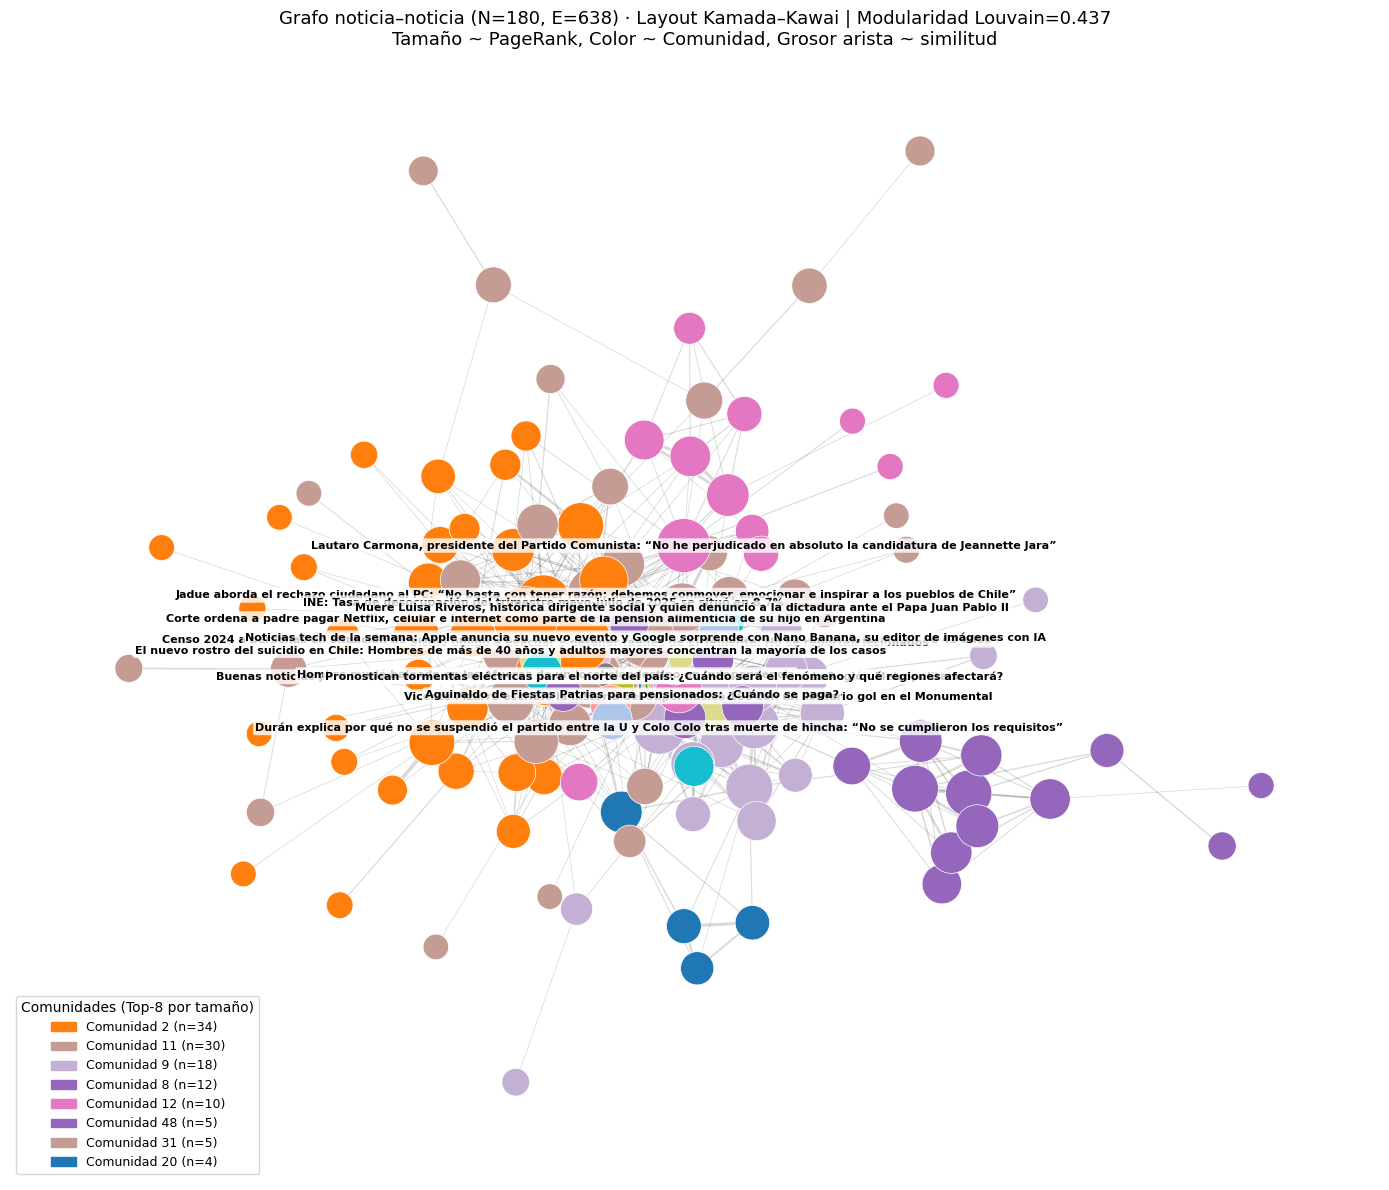

In [25]:
###Visualización del grafo noticia–noticia
#Layout elegido: Kamada–Kawai usando 'length = 1/similitud' como distancia.
#Justificación: al tratar la similitud como "cercanía", Kamada–Kawai busca posiciones
#que respeten distancias de camino; con 'length=1/weight' coloca JUNTAS las noticias
#más similares y separa las menos relacionadas. Es estable y legible para grafos medianos.

#Estilo:
#Tamaño de nodo ~ PageRank (ponderado por 'weight')
#Color de nodo ~ comunidad (Louvain)
#Grosor de arista ~ similitud (weight)
#Etiquetas solo para los nodos Top-15 por PageRank (evita ruido visual)
#
#Requisitos previos (ya cubiertos en bloques anteriores):
#G: grafo no dirigido con atributo 'weight' (similitud en [0,1]) y 'length'=1/weight
#df_cent: DataFrame con métricas, incluyendo 'pagerank' y 'community'
#df_comms/mod: resumen de comunidades y modularidad (si los calculaste en el Bloque 27/28)

#Cargar/recuperar grafo y datos mínimos si el kernel se reinició
CANDIDATOS = [Path.cwd()/ "datos", Path("/content/datos"), Path("/datos"), Path("/mnt/data/datos")]
DATOS_DIR = next((d for d in CANDIDATOS if d.exists() and d.is_dir()), None)
if DATOS_DIR is None:
    raise FileNotFoundError("No se encontró carpeta 'datos/'.")

if "G" not in globals():
    import json
    nodes = pd.read_csv(DATOS_DIR / "nodes_noticia.csv")
    edges = pd.read_csv(DATOS_DIR / "edges_noticia_noticia.csv")
    #enriquecer con corpus para títulos
    corpus_path = DATOS_DIR / "corpus_t2_limpio.json"
    DOCS = {}
    if corpus_path.exists():
        with open(corpus_path, "r", encoding="utf-8") as f:
            c = json.load(f)
        DOCS = {d["id"]: d for d in c.get("docs", [])}

    G = nx.Graph()
    for _, r in nodes.iterrows():
        nid = str(r["id"])
        meta = DOCS.get(nid, {})
        G.add_node(
            nid,
            tipo=meta.get("tipo", r.get("tipo")),
            categoria=meta.get("categoria", r.get("categoria")),
            fecha=meta.get("fecha", r.get("fecha")),
            titulo=meta.get("titulo_raw") or meta.get("titulo") or r.get("id"),
            agente=meta.get("agente"),
        )
    for _, r in edges.iterrows():
        u, v, w = str(r["source"]), str(r["target"]), float(r["weight"])
        if u != v and 0 <= w <= 1:
            G.add_edge(u, v, weight=w, length=(1.0/max(w, 1e-9)))

#Recalc PageRank si no esta df_cent:
if "df_cent" not in globals() or "pagerank" not in df_cent.columns:
    pr = nx.pagerank(G, alpha=0.85, weight="weight")
    rows = []
    for n in G.nodes():
        rows.append({
            "id": n,
            "titulo": G.nodes[n].get("titulo"),
            "agente": G.nodes[n].get("agente"),
            "categoria": G.nodes[n].get("categoria"),
            "pagerank": pr.get(n, 0.0),
            "degree": int(G.degree[n]),
            "community": G.nodes[n].get("community", -1),
        })
    df_cent = pd.DataFrame(rows)
else:
    #Asegurar columnas básicas presentes
    for col in ["titulo","agente","categoria"]:
        if col not in df_cent.columns:
            df_cent[col] = df_cent["id"].map(lambda x: G.nodes[x].get(col))
    if "community" not in df_cent.columns:
        df_cent["community"] = df_cent["id"].map(lambda x: G.nodes[x].get("community", -1))

##Layout Kamada–Kawai con distancia = 'length' (1/similitud)
use_length = all("length" in G[u][v] for u,v in G.edges())
if use_length:
    pos = nx.kamada_kawai_layout(G, weight="length")
else:
    #Fallback: spring layout ponderado por similitud
    pos = nx.spring_layout(G, weight="weight", seed=42)

##Preparar estilos (tamaños, colores, anchos)
#Tamaño ~ PageRank (escalado robusto)
pr_vals = df_cent.set_index("id")["pagerank"].reindex(G.nodes(), fill_value=0.0).values
if pr_vals.max() > pr_vals.min():
    pr_norm = (pr_vals - pr_vals.min()) / (pr_vals.max() - pr_vals.min())
else:
    pr_norm = np.zeros_like(pr_vals)

node_sizes = 300 + 2200 * pr_norm  # rango aprox [300, 2500]

#Colores por comunidad (discretos). Si hay muchas comunidades, hacemos wrap sobre 'tab20'
comm = df_cent.set_index("id")["community"].reindex(G.nodes(), fill_value=-1).values
unique_comms = [c for c in sorted(pd.unique(comm)) if c != -1]
comm_to_idx = {c: i for i, c in enumerate(unique_comms)}
comm_idx = np.array([comm_to_idx.get(c, -1) for c in comm])
#paleta
palette = mpl.cm.get_cmap("tab20", max(1, len(unique_comms) if len(unique_comms) <= 20 else 20))
colors = [palette(ci % 20) if ci >= 0 else (0.7,0.7,0.7,0.6) for ci in comm_idx]

#Grosor de aristas ~ similitud
w = np.array([G[u][v]["weight"] for u,v in G.edges()])
edge_widths = 0.5 + 2.5 * ((w - w.min()) / (w.max() - w.min() + 1e-9))  #[0.5, 3.0]
edge_alpha = 0.15

#Dibujo
plt.figure(figsize=(14, 12))
#Edges primero
nx.draw_networkx_edges(
    G, pos,
    width=edge_widths.tolist(),
    edge_color="k",
    alpha=edge_alpha
)
#Nodes
nodes_coll = nx.draw_networkx_nodes(
    G, pos,
    node_size=node_sizes.tolist(),
    node_color=colors,
    linewidths=0.5,
    edgecolors="white"
)

#Etiquetas: solo Top-15 por PageRank
top_labels = (
    df_cent.sort_values("pagerank", ascending=False)
           .head(15)
           .set_index("id")["titulo"]
           .to_dict()
)
label_pos = {n: pos[n] for n in top_labels.keys()}
nx.draw_networkx_labels(
    G, label_pos, labels=top_labels,
    font_size=8, font_weight="bold",
    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8)
)

#Leyenda de comunidades (Top-8 por tamaño)
if "community" in df_cent.columns:
    comm_sizes = df_cent.groupby("community")["id"].count().sort_values(ascending=False)
    top_comm_ids = [c for c in comm_sizes.index.tolist() if c != -1][:8]
    import matplotlib.patches as mpatches
    patches = []
    for c in top_comm_ids:
        ci = comm_to_idx.get(c, -1)
        if ci < 0:
            continue
        patches.append(mpatches.Patch(color=palette(ci % 20), label=f"Comunidad {c} (n={comm_sizes[c]})"))
    if patches:
        plt.legend(handles=patches, title="Comunidades (Top-8 por tamaño)", loc="lower left", fontsize=9, frameon=True)

#Título y créditos
N, E = G.number_of_nodes(), G.number_of_edges()
mod_txt = ""
if "mod" in globals():
    mod_txt = f" | Modularidad Louvain={mod:.3f}"
plt.title(f"Grafo noticia–noticia (N={N}, E={E}) · Layout Kamada–Kawai{mod_txt}\n"
          f"Tamaño ~ PageRank, Color ~ Comunidad, Grosor arista ~ similitud",
          fontsize=13)

plt.axis("off")
plt.tight_layout()

#Guardar imagen
out_path = DATOS_DIR / "grafo_noticias_visual.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
print(f"Figura guardada en: {out_path}")

## Conclusiones


Crea un archivo `README.md` y responde:

- **Relevancia temática:** ¿Qué **temas** (o comunidades) dominan el corpus? ¿Cómo los identificaste?

- **Noticias/Agentes influyentes:** ¿Qué noticias resultan **más influyentes** según **diferentes** centralidades? ¿Coinciden o difieren? ¿Por qué?

## Entregables

Un archivo comprimido `.zip` con nombre `T2_TEL351_Nombre_Apellido.zip` que contenga el **Jupyter Notebook** y **todos** los datos utilizados junto con el `README.md`.